<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/GW190814_Posterior_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GW190814_cosmo.h5 already exists; skipping download.
File size: 159.6 MB
Header bytes: b'\x89HDF\r\n\x1a\n'
Top-level keys: ['C01:IMRPhenomXPHM', 'C01:Mixed', 'history', 'version']
Using object: /C01:Mixed/posterior_samples
Object type: <class 'h5py._hl.dataset.Dataset'>

Loaded columns:
['temperature', 'mass_ratio', 'peak_luminosity', 'V1_time', 'cos_iota', 'final_mass_source', 'L1_spcal_phase_3', 'V1_spcal_phase_4', 'spin_2z', 'V1_spcal_amp_0', 'total_mass', 'H1_spcal_phase_4', 'spin_1z', 'log_likelihood', 'loglH1', 'chain_delta_log_evidence', 'psi_J', 'radiated_energy', 'H1_spcal_amp_7', 'L1_spcal_amp_9', 'L1_time', 'redshift', 'H1_time', 'chain_log_bayes_factor', 'mass_2_source', 'H1_spcal_phase_0', 'V1_spcal_amp_7', 'L1_spcal_amp_4', 'cos_theta_jn', 'V1_matched_filter_snr', 'inverted_mass_ratio', 'total_mass_source', 'H1_spcal_phase_3', 'psi', 'L1_spcal_amp_3', 'symmetric_mass_ratio', 'H1_spcal_amp_3', 'H1_spcal_phase_1', 'L1_spcal_amp_8', 'L1_spcal_phase_2', 'L1_matched_filter_sn

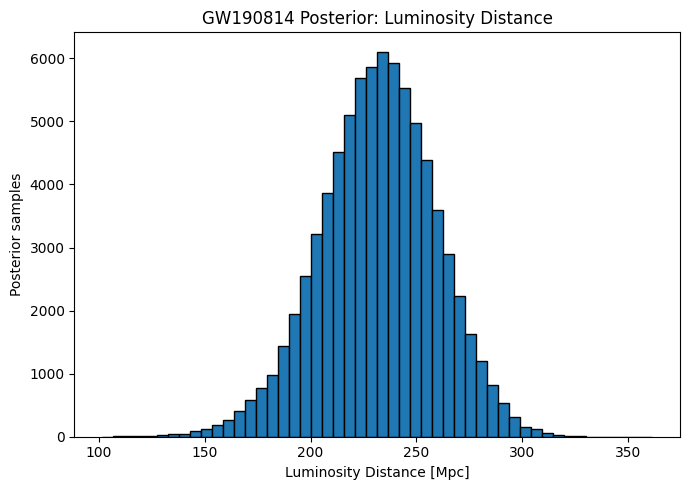

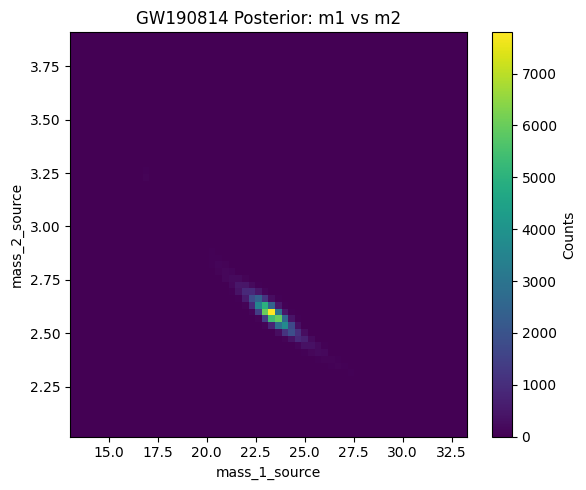

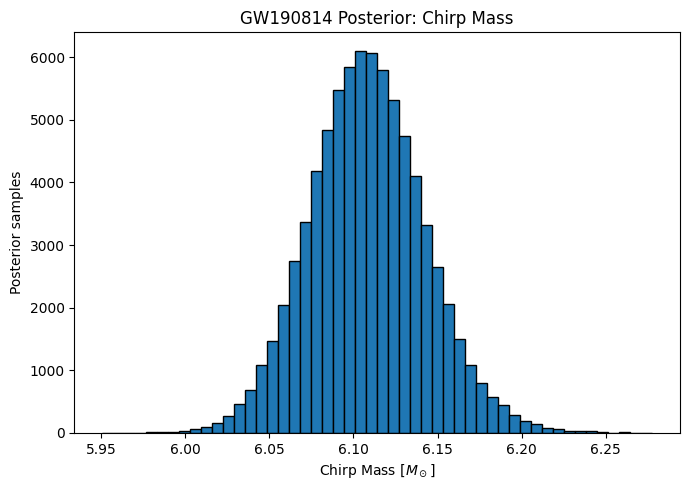

In [4]:
import os
import requests
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False


# ============================================================
# CONFIG
# ============================================================
URL = "https://zenodo.org/records/6513631/files/IGWN-GWTC2p1-v2-GW190814_211039_PEDataRelease_mixed_cosmo.h5?download=1"
POSTERIOR_FILE = "GW190814_cosmo.h5"


# ============================================================
# DOWNLOAD
# ============================================================
def download_file(url, output_path, chunk_size=1024 * 1024):
    print(f"Downloading to {output_path} ...")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0

        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total > 0:
                        pct = 100 * downloaded / total
                        print(f"\r{downloaded/1024**2:7.1f} MB / {total/1024**2:7.1f} MB ({pct:5.1f}%)", end="")
    print("\nDownload complete.")


if not os.path.exists(POSTERIOR_FILE):
    download_file(URL, POSTERIOR_FILE)
else:
    print(f"{POSTERIOR_FILE} already exists; skipping download.")


# ============================================================
# SANITY CHECK
# ============================================================
size_mb = os.path.getsize(POSTERIOR_FILE) / (1024**2)
print(f"File size: {size_mb:.1f} MB")

with open(POSTERIOR_FILE, "rb") as f:
    header = f.read(8)

print("Header bytes:", header)
if header != b"\x89HDF\r\n\x1a\n":
    raise ValueError("Downloaded file is not a valid HDF5 file.")


# ============================================================
# HELPERS
# ============================================================
def find_posterior_object(h5obj):
    """
    Locate the posterior samples object in common GW posterior layouts.
    Returns either an h5py Group or Dataset.
    """
    candidate_paths = [
        "posterior_samples",
        "samples",
        "C01:Mixed/posterior_samples",
        "C01:Mixed",
        "PublicationSamples/posterior_samples",
        "PublicationSamples",
    ]

    for path in candidate_paths:
        if path in h5obj:
            return h5obj[path]

    found = []

    def visitor(name, obj):
        if name.endswith("posterior_samples"):
            found.append(name)

    h5obj.visititems(visitor)

    if found:
        print("Found posterior object:", found[0])
        return h5obj[found[0]]

    raise ValueError("Could not find posterior samples in this HDF5 file.")


def object_to_dataframe(obj):
    """
    Convert either:
      - an HDF5 Group of 1D datasets
      - or a structured HDF5 Dataset
    into a pandas DataFrame.
    """
    # Case 1: structured dataset
    if isinstance(obj, h5py.Dataset):
        arr = obj[()]
        if arr.dtype.names is None:
            raise ValueError("Dataset found, but it is not a structured array with named fields.")
        return pd.DataFrame({name: arr[name] for name in arr.dtype.names})

    # Case 2: group of datasets
    elif isinstance(obj, h5py.Group):
        data = {}
        lengths = []

        for key in obj.keys():
            item = obj[key]
            if isinstance(item, h5py.Dataset):
                arr = item[()]
                if np.ndim(arr) == 1:
                    data[key] = arr
                    lengths.append(len(arr))

        if not data:
            raise ValueError("No suitable 1D datasets found in posterior group.")

        from collections import Counter
        target_len = Counter(lengths).most_common(1)[0][0]
        data = {k: v for k, v in data.items() if len(v) == target_len}

        return pd.DataFrame(data)

    else:
        raise TypeError(f"Unsupported HDF5 object type: {type(obj)}")


def load_posterior_dataframe(filename):
    with h5py.File(filename, "r") as f:
        print("Top-level keys:", list(f.keys()))
        obj = find_posterior_object(f)
        print("Using object:", obj.name)
        print("Object type:", type(obj))
        df = object_to_dataframe(obj)
    return df


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")


# ============================================================
# LOAD POSTERIORS
# ============================================================
df = load_posterior_dataframe(POSTERIOR_FILE)

print("\nLoaded columns:")
print(df.columns.tolist())
print(f"\nLoaded {len(df)} posterior samples")


# ============================================================
# IDENTIFY PARAMETERS
# ============================================================
dL_col = first_existing_column(df, ["luminosity_distance", "distance", "dL"])
m1_col = first_existing_column(df, ["mass_1_source", "mass_1", "m1_source", "m1"])
m2_col = first_existing_column(df, ["mass_2_source", "mass_2", "m2_source", "m2"])

chirp_col = None
for c in ["chirp_mass_source", "chirp_mass", "chirp_mass_source_non_evolved", "mc_source", "mc"]:
    if c in df.columns:
        chirp_col = c
        break

if chirp_col is None:
    df["chirp_mass_computed"] = (
        (df[m1_col] * df[m2_col]) ** (3/5)
        / (df[m1_col] + df[m2_col]) ** (1/5)
    )
    chirp_col = "chirp_mass_computed"

print("\nUsing columns:")
print(" distance  =", dL_col)
print(" mass 1    =", m1_col)
print(" mass 2    =", m2_col)
print(" chirp mass=", chirp_col)


# ============================================================
# 1) HISTOGRAM OF LUMINOSITY DISTANCE
# ============================================================
plt.figure(figsize=(7, 5))
plt.hist(df[dL_col].dropna(), bins=50, edgecolor="black")
plt.xlabel("Luminosity Distance [Mpc]")
plt.ylabel("Posterior samples")
plt.title("GW190814 Posterior: Luminosity Distance")
plt.tight_layout()
plt.show()


# ============================================================
# 2) M1 VS M2 CORNER-STYLE PLOT
# ============================================================
samples_m1m2 = df[[m1_col, m2_col]].dropna().values

if HAS_CORNER:
    fig = corner.corner(
        samples_m1m2,
        labels=[m1_col, m2_col],
        show_titles=True,
        title_fmt=".2f",
        bins=40,
        smooth=1.0
    )
    fig.suptitle("GW190814 Posterior: m1 vs m2", y=1.02)
    plt.show()
else:
    plt.figure(figsize=(6, 5))
    plt.hist2d(df[m1_col], df[m2_col], bins=60)
    plt.xlabel(m1_col)
    plt.ylabel(m2_col)
    plt.title("GW190814 Posterior: m1 vs m2")
    plt.colorbar(label="Counts")
    plt.tight_layout()
    plt.show()


# ============================================================
# 3) HISTOGRAM OF CHIRP MASS
# ============================================================
plt.figure(figsize=(7, 5))
plt.hist(df[chirp_col].dropna(), bins=50, edgecolor="black")
plt.xlabel("Chirp Mass [$M_\\odot$]")
plt.ylabel("Posterior samples")
plt.title("GW190814 Posterior: Chirp Mass")
plt.tight_layout()
plt.show()

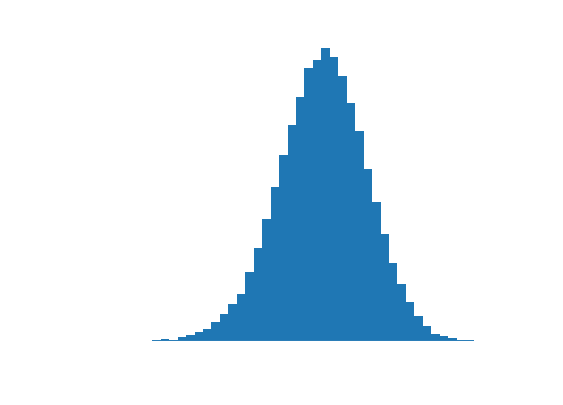

In [36]:
import matplotlib.pyplot as plt

# Your data
d = df[dL_col].dropna()

fig, ax = plt.subplots(figsize=(6, 4))

# Histogram
ax.hist(d, bins=50)

# Labels (poster-friendly wording optional)
ax.set_xlabel("Distance [Mpc]", color="white")
ax.set_ylabel("Posterior samples", color="white")
ax.set_title("GW190814: estimated distance", color="white")

# White ticks
ax.tick_params(colors="white")

# White spines
for spine in ax.spines.values():
    spine.set_color("white")

# Remove grid (cleaner)
ax.grid(False)

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# Save
fig.savefig("gw190814_distance.png", dpi=300, transparent=True, bbox_inches="tight")

plt.show()

In [32]:
median = d.median()
ax.axvline(median, linestyle="--")

ax.text(
    median,
    ax.get_ylim()[1] * 0.85,
    f"{median:.0f} Mpc",
    color="white",
    ha="center"
)

Text(232.69868857798014, 5450.4975, '233 Mpc')

In [33]:
median_ly = median * 3.26e6

ax.text(
    median,
    ax.get_ylim()[1] * 0.7,
    f"~{median_ly/1e6:.0f} million light-years",
    color="white",
    ha="center"
)

Text(232.69868857798014, 4488.6449999999995, '~759 million light-years')

In [34]:
import numpy as np
from scipy.stats import gaussian_kde

x = np.linspace(d.min(), d.max(), 500)
kde = gaussian_kde(d)

ax.plot(x, kde(x) * len(d) * (x[1]-x[0]))

In [35]:
d = df[dL_col].dropna()

median = d.median()
median_ly = median * 3.26e6

ax.axvline(median, linestyle="--")

ax.text(
    median,
    ax.get_ylim()[1] * 0.7,
    f"~{median_ly/1e6:.0f} million light-years",
    color="white",
    ha="center"
)

Text(232.69868857798014, 4488.6449999999995, '~759 million light-years')

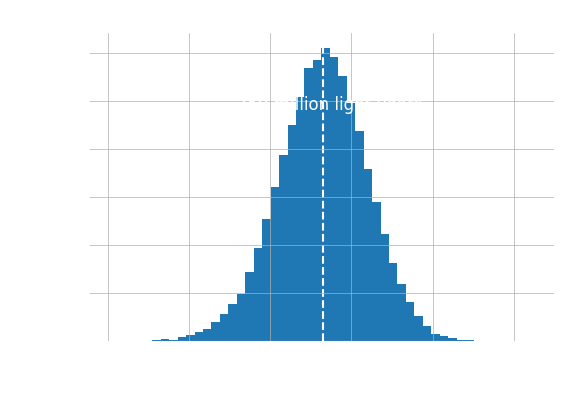

In [37]:
import matplotlib.pyplot as plt

d = df[dL_col].dropna()

fig, ax = plt.subplots(figsize=(6, 4))

# Histogram
ax.hist(d, bins=50)

# Median + conversion
median = d.median()
MPC_TO_LY = 3.26156e6
median_ly = median * MPC_TO_LY

# Vertical line
ax.axvline(median, linestyle="--", color="white")

# Annotation ON the plot
ax.text(
    median,
    ax.get_ylim()[1] * 0.75,
    f"~{median_ly/1e6:.0f} million light-years",
    color="white",
    ha="center"
)

# Styling
ax.set_xlabel("Distance [Mpc]", color="white")
ax.set_ylabel("Posterior samples", color="white")
ax.set_title("GW190814: estimated distance", color="white")

ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.show()

In [8]:
!pip install corner

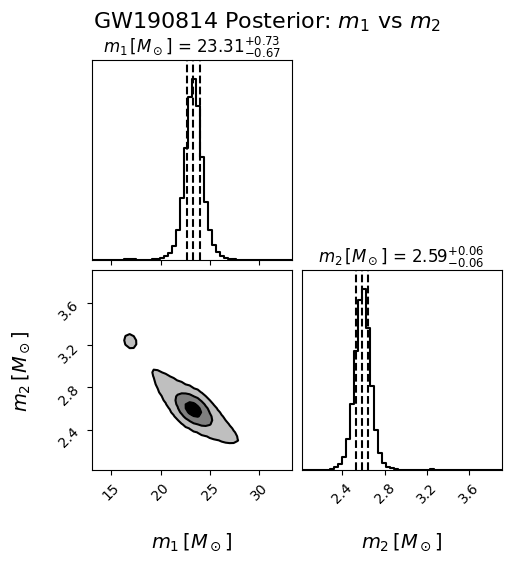

In [9]:
import corner
import matplotlib.pyplot as plt

samples_m1m2 = df[[m1_col, m2_col]].dropna().values

fig = corner.corner(
    samples_m1m2,
    labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$"],
    bins=50,
    smooth=1.2,
    smooth1d=1.2,
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.393, 0.865, 0.989),   # ~1σ, 2σ, 3σ for 2D contours
    plot_density=True,
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=5,
    label_kwargs={"fontsize": 14},
    title_kwargs={"fontsize": 12},
)

fig.suptitle("GW190814 Posterior: $m_1$ vs $m_2$", y=1.02, fontsize=16)
plt.show()

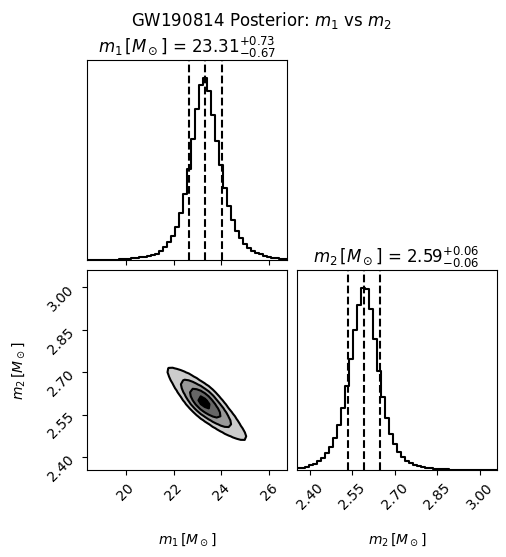

In [10]:
m1 = df[m1_col].dropna()
m2 = df[m2_col].dropna()

m1_lo, m1_hi = np.percentile(m1, [0.5, 99.5])
m2_lo, m2_hi = np.percentile(m2, [0.5, 99.5])

samples_m1m2 = df[[m1_col, m2_col]].dropna().values

fig = corner.corner(
    samples_m1m2,
    labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$"],
    range=[(m1_lo, m1_hi), (m2_lo, m2_hi)],
    bins=50,
    smooth=1.0,
    smooth1d=1.0,
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=False,
    fill_contours=True,
    plot_density=True,
    max_n_ticks=5,
)

fig.suptitle("GW190814 Posterior: $m_1$ vs $m_2$", y=1.02)
plt.show()

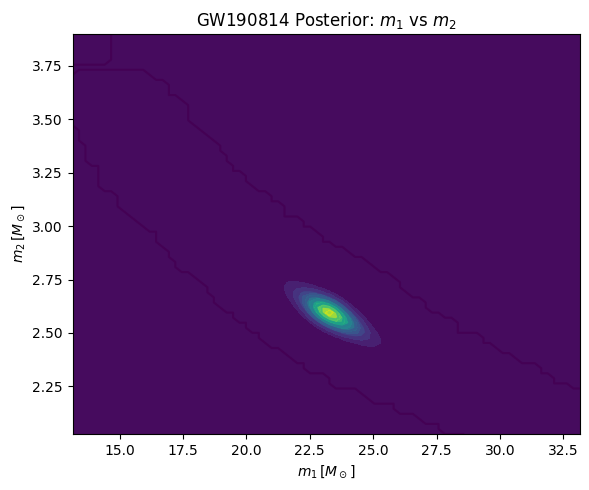

In [7]:
from scipy.ndimage import gaussian_filter

m1 = df[m1_col].dropna().values
m2 = df[m2_col].dropna().values

H, xedges, yedges = np.histogram2d(m1, m2, bins=80)
H = gaussian_filter(H, sigma=1.2)

xcent = 0.5 * (xedges[:-1] + xedges[1:])
ycent = 0.5 * (yedges[:-1] + yedges[1:])

plt.figure(figsize=(6, 5))
plt.contourf(xcent, ycent, H.T, levels=20)
plt.contour(xcent, ycent, H.T, levels=6)
plt.xlabel(r"$m_1\,[M_\odot]$")
plt.ylabel(r"$m_2\,[M_\odot]$")
plt.title("GW190814 Posterior: $m_1$ vs $m_2$")
plt.tight_layout()
plt.show()

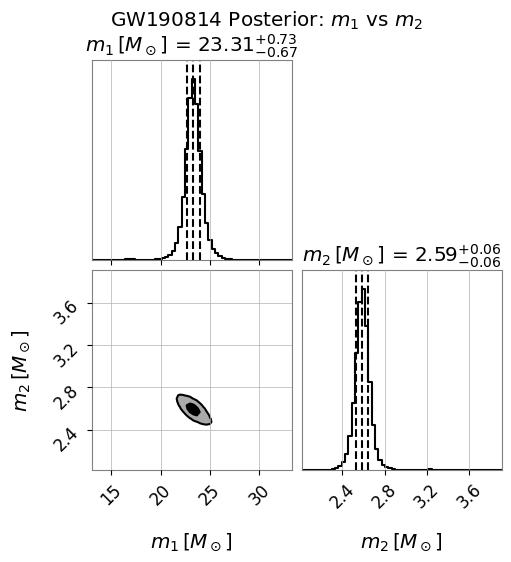

In [22]:
import corner
import matplotlib.pyplot as plt
import numpy as np

m1 = df[m1_col].dropna()
m2 = df[m2_col].dropna()

samples = np.vstack([m1, m2]).T

fig = corner.corner(
    samples,
    labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$"],
    bins=60,
    smooth=1.0,
    smooth1d=1.0,
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.393, 0.865),  # ~1σ and 2σ (cleaner than 3 levels)
    plot_datapoints=False,
    fill_contours=True,
    plot_density=True,
    max_n_ticks=5,
)

fig.suptitle("GW190814 Posterior: $m_1$ vs $m_2$", y=1.02)
plt.show()

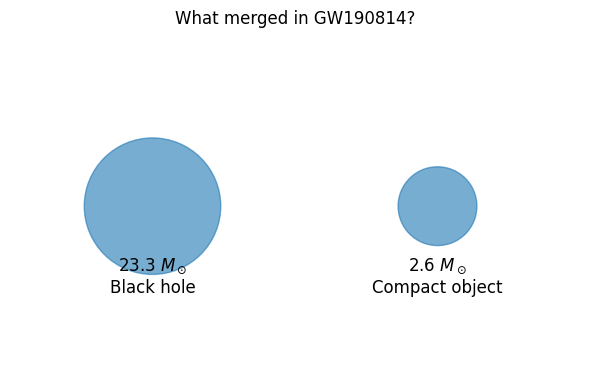

In [12]:
import matplotlib.pyplot as plt

m1 = df[m1_col].median()
m2 = df[m2_col].median()

fig, ax = plt.subplots(figsize=(6, 4))

# Draw circles scaled by sqrt(mass) for visual balance
sizes = [m1**0.5 * 2000, m2**0.5 * 2000]

ax.scatter([0, 2], [0, 0], s=sizes, alpha=0.6)

ax.text(0, -0.5, f"{m1:.1f} $M_\\odot$\nBlack hole",
        ha='center', fontsize=12)

ax.text(2, -0.5, f"{m2:.1f} $M_\\odot$\nCompact object",
        ha='center', fontsize=12)

ax.set_xlim(-1, 3)
ax.set_ylim(-1, 1)
ax.axis('off')

plt.title("What merged in GW190814?")
plt.tight_layout()
plt.show()

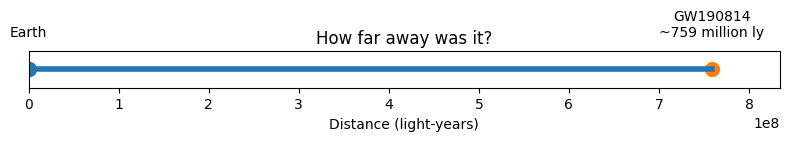

In [13]:
import matplotlib.pyplot as plt

distance_mpc = df[dL_col].median()
distance_ly = distance_mpc * 3.26e6  # convert Mpc → light-years

fig, ax = plt.subplots(figsize=(8, 2))

ax.plot([0, distance_ly], [0, 0], linewidth=4)

# markers
ax.scatter([0], [0], s=100)
ax.text(0, 0.1, "Earth", ha='center')

ax.scatter([distance_ly], [0], s=100)
ax.text(distance_ly, 0.1,
        f"GW190814\n~{distance_ly/1e6:.0f} million ly",
        ha='center')

ax.set_yticks([])
ax.set_xlabel("Distance (light-years)")
ax.set_xlim(0, distance_ly * 1.1)

plt.title("How far away was it?")
plt.tight_layout()
plt.show()

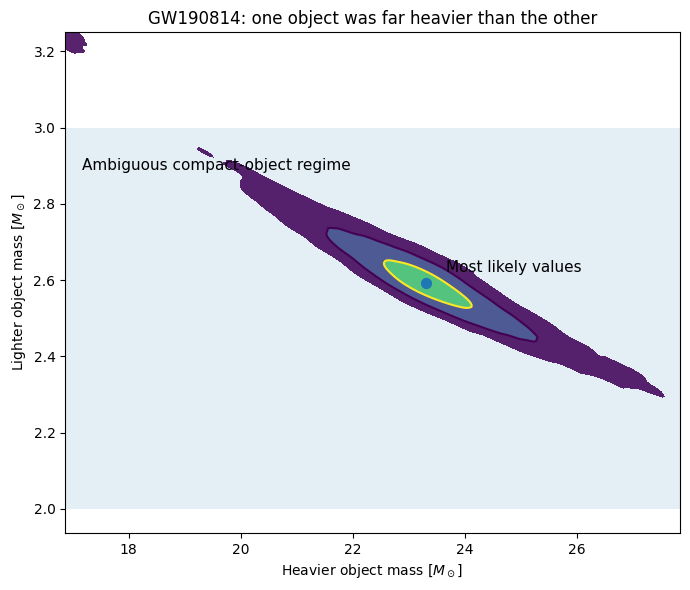

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

m1 = df[m1_col].dropna().values
m2 = df[m2_col].dropna().values

# KDE on a grid
xmin, xmax = np.percentile(m1, [0.2, 99.8])
ymin, ymax = np.percentile(m2, [0.2, 99.8])

xx, yy = np.mgrid[xmin:xmax:250j, ymin:ymax:250j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([m1, m2])
kde = gaussian_kde(values)
f = np.reshape(kde(positions).T, xx.shape)

# Credible contour levels
flat = np.sort(f.ravel())[::-1]
cdf = np.cumsum(flat)
cdf /= cdf[-1]

def contour_level(prob):
    return flat[np.searchsorted(cdf, prob)]

lvl_50 = contour_level(0.50)
lvl_90 = contour_level(0.90)
lvl_99 = contour_level(0.99)

fig, ax = plt.subplots(figsize=(7, 6))

# Optional shaded “interesting regime” band for the lighter object
ax.axhspan(2.0, 3.0, alpha=0.12)
ax.text(xmin + 0.3, 2.92, "Ambiguous compact-object regime", fontsize=11, va="top")

# Filled contours
ax.contourf(xx, yy, f, levels=[lvl_99, lvl_90, lvl_50, f.max()], alpha=0.9)
ax.contour(xx, yy, f, levels=[lvl_90, lvl_50], linewidths=1.5)

# Median point
m1_med = np.median(m1)
m2_med = np.median(m2)
ax.scatter([m1_med], [m2_med], s=50, zorder=5)
ax.text(m1_med + 0.35, m2_med + 0.03, "Most likely values", fontsize=11)

ax.set_xlabel("Heavier object mass [$M_\\odot$]")
ax.set_ylabel("Lighter object mass [$M_\\odot$]")
ax.set_title("GW190814: one object was far heavier than the other")
plt.tight_layout()
plt.show()

/tmp/ipykernel_828/1186802051.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


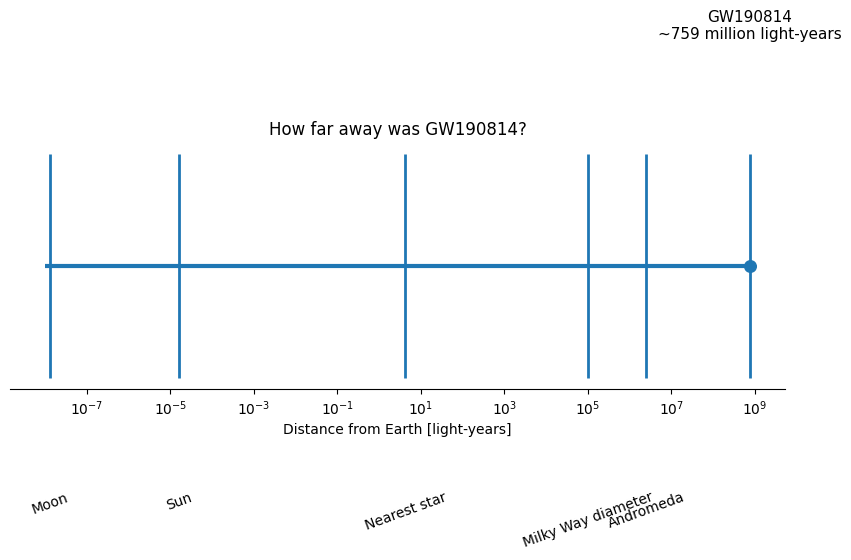

In [15]:
import numpy as np
import matplotlib.pyplot as plt

distance_mpc = np.median(df[dL_col].dropna().values)
distance_ly = distance_mpc * 3.26156e6

refs = [
    ("Moon", 1.28e-8),             # ly
    ("Sun", 1.58e-5),
    ("Nearest star", 4.24),
    ("Milky Way diameter", 1.0e5),
    ("Andromeda", 2.5e6),
    ("GW190814", distance_ly),
]

fig, ax = plt.subplots(figsize=(10, 3.2))

# main line
ax.hlines(0, 1e-8, distance_ly, linewidth=3)

for name, d in refs:
    ax.vlines(d, -0.08, 0.08, linewidth=2)
    if name == "GW190814":
        ax.scatter([d], [0], s=70, zorder=5)
        ax.text(d, 0.16, f"{name}\n~{distance_ly/1e6:.0f} million light-years",
                ha="center", va="bottom", fontsize=11)
    else:
        ax.text(d, -0.16, name, ha="center", va="top", fontsize=10, rotation=20)

ax.set_xscale("log")
ax.set_yticks([])
ax.set_xlabel("Distance from Earth [light-years]")
ax.set_title("How far away was GW190814?")
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

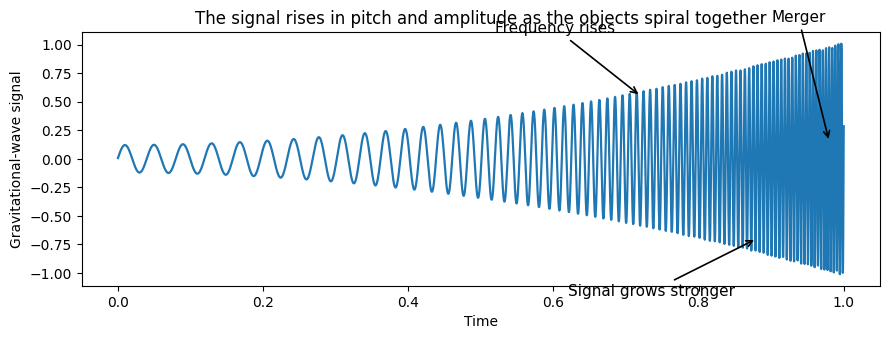

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Stylized chirp, not detector data
t = np.linspace(0, 1, 3000)
freq = 25 + 220 * t**3
phase = 2 * np.pi * np.cumsum(freq) * (t[1] - t[0])
amp = 0.12 + 0.9 * t**2
signal = amp * np.sin(phase)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t, signal, linewidth=1.6)

ax.annotate("Frequency rises", xy=(0.72, 0.55), xytext=(0.52, 1.1),
            arrowprops=dict(arrowstyle="->", lw=1.2), fontsize=11)
ax.annotate("Signal grows stronger", xy=(0.88, -0.7), xytext=(0.62, -1.2),
            arrowprops=dict(arrowstyle="->", lw=1.2), fontsize=11)
ax.annotate("Merger", xy=(0.98, 0.15), xytext=(0.90, 1.2),
            arrowprops=dict(arrowstyle="->", lw=1.2), fontsize=11)

ax.set_xlabel("Time")
ax.set_ylabel("Gravitational-wave signal")
ax.set_title("The signal rises in pitch and amplitude as the objects spiral together")
plt.tight_layout()
plt.show()

In [18]:
!pip install gwpy gwosc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.4 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.5 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.5 which is incompatible.


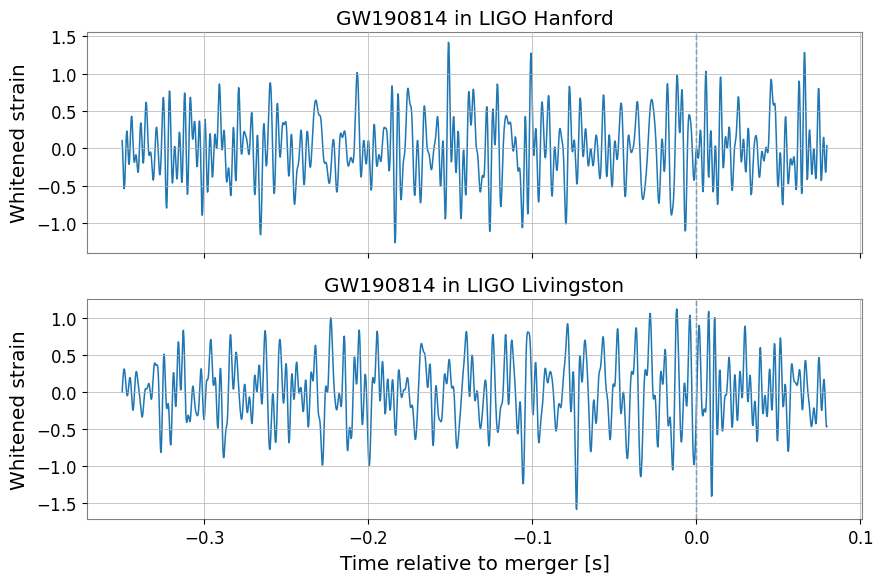

In [19]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

gps = 1249852257.0
start = gps - 16
end   = gps + 16

h1 = TimeSeries.fetch_open_data("H1", start, end, cache=True)
l1 = TimeSeries.fetch_open_data("L1", start, end, cache=True)

h1p = h1.whiten(4, 2).bandpass(35, 350).crop(gps - 0.35, gps + 0.08)
l1p = l1.whiten(4, 2).bandpass(35, 350).crop(gps - 0.35, gps + 0.08)

th = h1p.times.value - gps
tl = l1p.times.value - gps

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(th, h1p.value, lw=1.1)
axes[0].axvline(0, ls="--", lw=1)
axes[0].set_ylabel("Whitened strain")
axes[0].set_title("GW190814 in LIGO Hanford")

axes[1].plot(tl, l1p.value, lw=1.1)
axes[1].axvline(0, ls="--", lw=1)
axes[1].set_ylabel("Whitened strain")
axes[1].set_xlabel("Time relative to merger [s]")
axes[1].set_title("GW190814 in LIGO Livingston")

plt.tight_layout()
plt.show()

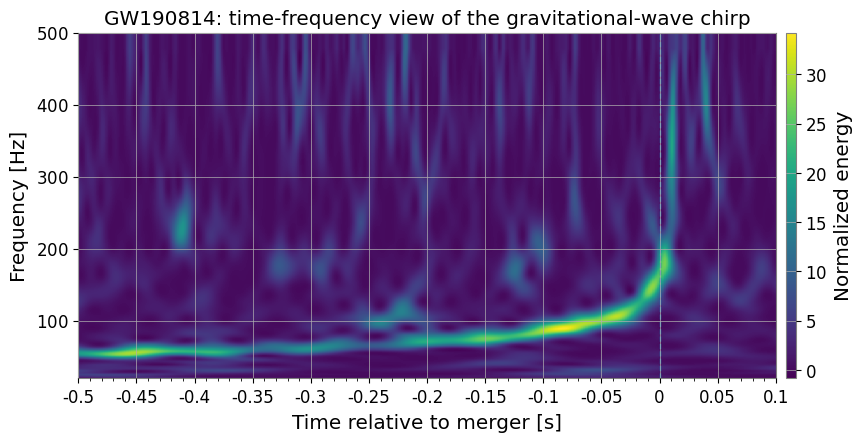

In [24]:
# Install once in Colab if needed
!pip -q install gwpy gwosc

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

gps = 1249852257.0
start = gps - 8
end   = gps + 8

data = TimeSeries.fetch_open_data("L1", start, end, cache=True)

# Whitening helps the chirp stand out
white = data.whiten(4, 2)

qspec = white.q_transform(
    outseg=(gps - 0.5, gps + 0.1),
    frange=(20, 500),
    qrange=(8, 32),
)

plot = qspec.plot(figsize=[9, 4.8])
ax = plot.gca()
ax.set_xscale("seconds", epoch=gps)
ax.set_xlabel("Time relative to merger [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("GW190814: time-frequency view of the gravitational-wave chirp")
ax.axvline(gps, ls="--", lw=1)
plot.colorbar(label="Normalized energy")
plot.show()

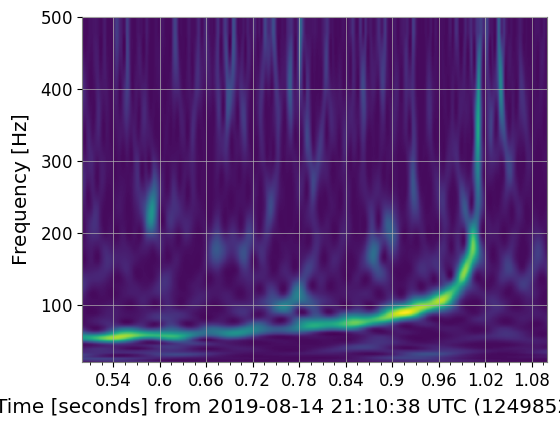

In [25]:
plot = qspec.plot(figsize=[6, 4.8])  # 9 → 6 (≈ 2/3 width)

Text(0.5, 0, 'Time relative to merger [s]')

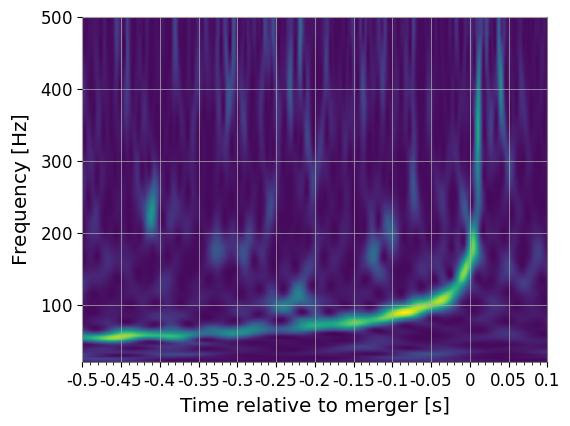

In [26]:
plot = qspec.plot(figsize=[6, 4.8])
ax = plot.gca()

ax.set_xscale("seconds", epoch=gps)
ax.set_xlabel("Time relative to merger [s]")

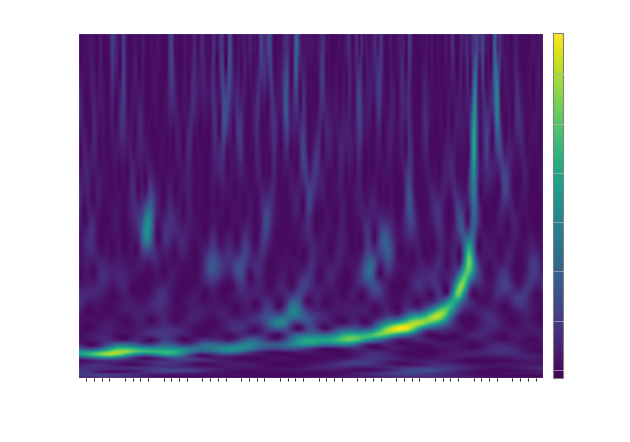

In [28]:
plot = qspec.plot(figsize=[6, 4.8])
ax = plot.gca()

# --- Axis formatting ---
ax.set_xscale("seconds", epoch=gps)
ax.set_xlabel("Time relative to merger [s]", color="white")
ax.set_ylabel("Frequency [Hz]", color="white")
ax.set_title("GW190814: gravitational-wave chirp", color="white")

# --- White ticks ---
ax.tick_params(colors="white")

# --- White spines ---
for spine in ax.spines.values():
    spine.set_color("white")

# --- Remove grid (cleaner) ---
ax.grid(False)

# --- Transparent background ---
fig = plot.figure   # <-- FIXED LINE
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# --- Colorbar styling ---
cbar = plot.colorbar()
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")
cbar.set_label("Signal strength", color="white")

# --- Save ---
fig.savefig("gw190814_qtransform.png", dpi=300, transparent=True, bbox_inches="tight")

plt.show()

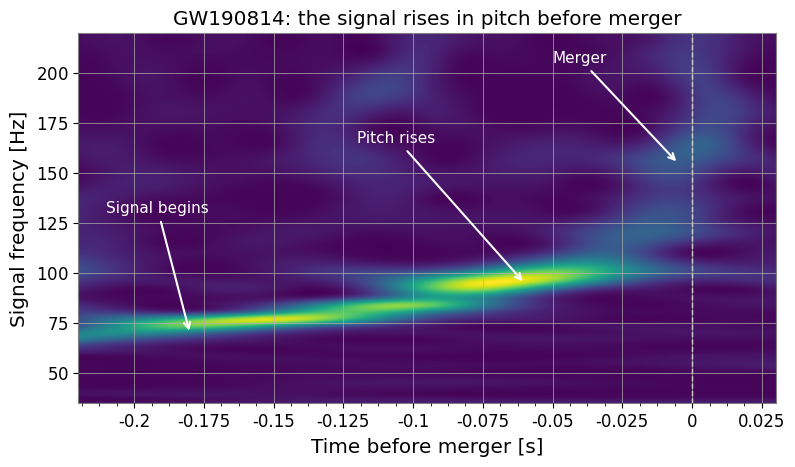

In [23]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

gps = 1249852257.0
start = gps - 4
end   = gps + 1

data = TimeSeries.fetch_open_data("L1", start, end, cache=True)
white = data.whiten(4, 2)

qspec = white.q_transform(
    outseg=(gps - 0.22, gps + 0.03),
    frange=(35, 220),
    qrange=(8, 32),
)

plot = qspec.plot(figsize=[9, 5])
ax = plot.gca()
ax.set_xscale("seconds", epoch=gps)
ax.set_xlabel("Time before merger [s]")
ax.set_ylabel("Signal frequency [Hz]")
ax.set_title("GW190814: the signal rises in pitch before merger")

# Optional: remove the vertical merger line if it clutters things
ax.axvline(gps, ls="--", lw=1, color="white")

# Annotate the chirp
ax.annotate(
    "Signal begins",
    xy=(gps - 0.18, 70),
    xytext=(gps - 0.21, 130),
    color="white",
    arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
    fontsize=11,
)

ax.annotate(
    "Pitch rises",
    xy=(gps - 0.06, 95),
    xytext=(gps - 0.12, 165),
    color="white",
    arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
    fontsize=11,
)

ax.annotate(
    "Merger",
    xy=(gps - 0.005, 155),
    xytext=(gps - 0.05, 205),
    color="white",
    arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
    fontsize=11,
)

plot.show()

In [29]:
import numpy as np

# qspec is your Q-transform result
f_axis = qspec.frequencies.value
t_axis = qspec.times.value

# Find time near merger
idx_t = np.argmin(np.abs(t_axis - gps))

# Find frequency of max power at that time
power_slice = qspec.value[:, idx_t]
f_peak = f_axis[np.argmax(power_slice)]

print(f"Peak frequency ≈ {f_peak:.0f} Hz")

Peak frequency ≈ 469 Hz


In [38]:
!pip install healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 58.2 MB/s eta 0:00:00


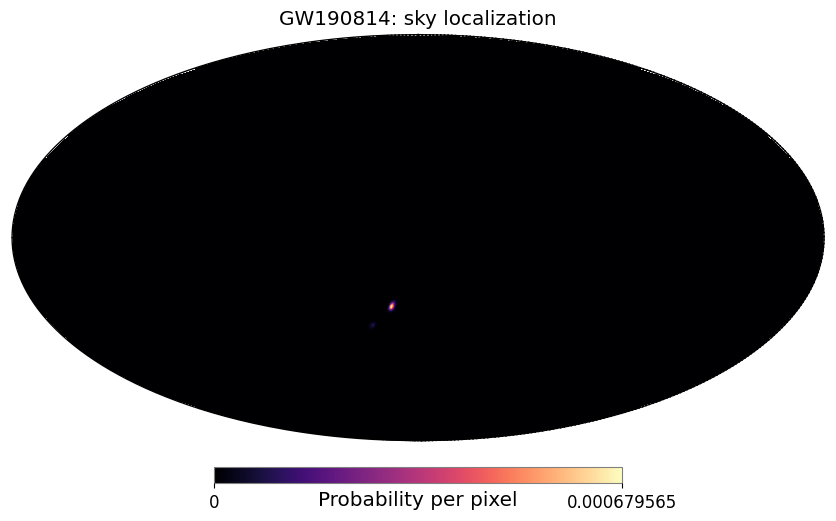

In [39]:
import healpy as hp
import matplotlib.pyplot as plt

skymap_file = "GW190814_skymap.fits.gz"

# Read the probability map
prob = hp.read_map(skymap_file, field=0)

# Plot
hp.mollview(
    prob,
    title="GW190814: sky localization",
    unit="Probability per pixel",
    cmap="magma"
)

hp.graticule()
plt.show()

/usr/local/lib/python3.12/dist-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


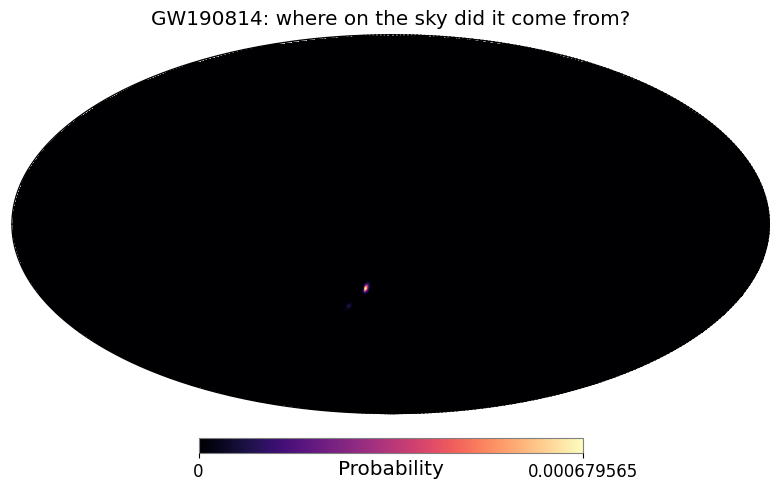

In [40]:
import healpy as hp
import matplotlib.pyplot as plt

skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0)

plt.figure(figsize=(8, 5), facecolor="none")

hp.mollview(
    prob,
    fig=1,
    title="GW190814: where on the sky did it come from?",
    unit="Probability",
    cmap="magma",
    cbar=True,
    notext=False
)

hp.graticule()
plt.show()

Centering on RA=12.66, Dec=-24.83


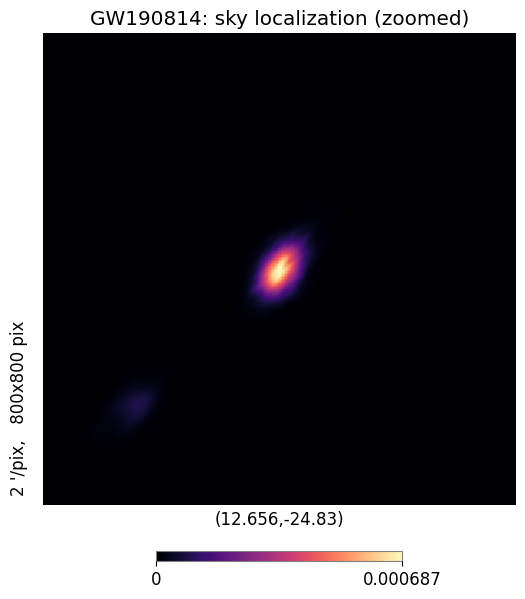

In [41]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0)

# Find peak location
ipix_max = np.argmax(prob)
theta, phi = hp.pix2ang(hp.get_nside(prob), ipix_max)

# Convert to degrees
ra = np.degrees(phi)
dec = 90 - np.degrees(theta)

print(f"Centering on RA={ra:.2f}, Dec={dec:.2f}")

# Plot zoomed map
hp.gnomview(
    prob,
    rot=(ra, dec),
    xsize=800,
    reso=2.0,
    title="GW190814: sky localization (zoomed)",
    cmap="magma"
)

plt.show()

In [42]:
!pip install healpy astropy scipy

/tmp/ipykernel_828/164676920.py:12: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob = hp.read_map(skymap_file, field=0, verbose=False)


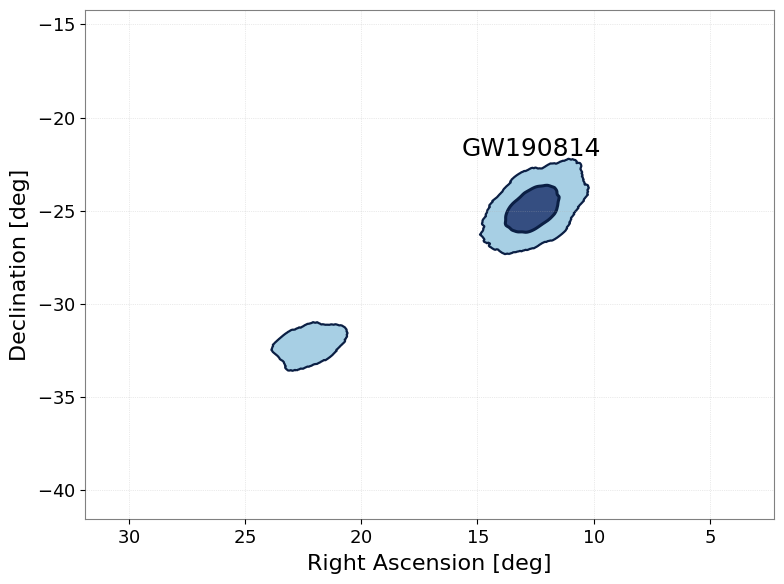

In [43]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from astropy.coordinates import Angle
import astropy.units as u

# --------------------------------------------------
# Load GW190814 skymap
# --------------------------------------------------
skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0, verbose=False)

nside = hp.get_nside(prob)
npix = len(prob)

# --------------------------------------------------
# Compute greedy credible levels
# --------------------------------------------------
order = np.argsort(prob)[::-1]
cdf = np.cumsum(prob[order])
credible = np.empty_like(prob)
credible[order] = cdf

# --------------------------------------------------
# Pixel coordinates -> RA, Dec
# --------------------------------------------------
ipix = np.arange(npix)
theta, phi = hp.pix2ang(nside, ipix)

ra = np.degrees(phi)              # 0 to 360
dec = 90 - np.degrees(theta)      # -90 to +90

# --------------------------------------------------
# Center RA near the peak so the region isn't split
# --------------------------------------------------
peak = np.argmax(prob)
peak_ra = ra[peak]
peak_dec = dec[peak]

ra_wrapped = Angle(ra * u.deg).wrap_at((peak_ra + 180) * u.deg).degree

# --------------------------------------------------
# Focus on the 90% region with a margin
# --------------------------------------------------
mask90 = credible <= 0.9

ra90 = ra_wrapped[mask90]
dec90 = dec[mask90]

margin_ra = 8   # degrees
margin_dec = 8  # degrees

ra_min = ra90.min() - margin_ra
ra_max = ra90.max() + margin_ra
dec_min = dec90.min() - margin_dec
dec_max = dec90.max() + margin_dec

# --------------------------------------------------
# Interpolate credible levels onto a regular grid
# --------------------------------------------------
nx, ny = 500, 500
ra_grid, dec_grid = np.meshgrid(
    np.linspace(ra_min, ra_max, nx),
    np.linspace(dec_min, dec_max, ny)
)

cred_grid = griddata(
    points=np.column_stack([ra_wrapped, dec]),
    values=credible,
    xi=(ra_grid, dec_grid),
    method="linear"
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# subtle fills
ax.contourf(
    ra_grid, dec_grid, cred_grid,
    levels=[0, 0.5, 0.9],
    colors=["#1f3b73", "#9ecae1"],   # dark + light blue
    alpha=0.9
)

# contour outlines
ax.contour(
    ra_grid, dec_grid, cred_grid,
    levels=[0.5, 0.9],
    colors=["#0b1f44", "#0b1f44"],
    linewidths=[2.2, 1.6]
)

# label near peak
ax.text(
    peak_ra if peak_ra < 180 else peak_ra - 360,
    peak_dec + 2.5,
    "GW190814",
    fontsize=18,
    ha="center",
    va="bottom"
)

# axes
ax.set_xlabel("Right Ascension [deg]", fontsize=16)
ax.set_ylabel("Declination [deg]", fontsize=16)

# reverse RA axis to match astronomy convention
ax.set_xlim(ra_max, ra_min)
ax.set_ylim(dec_min, dec_max)

# grid
ax.grid(True, linestyle=":", alpha=0.5)

# nice tick label sizes
ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

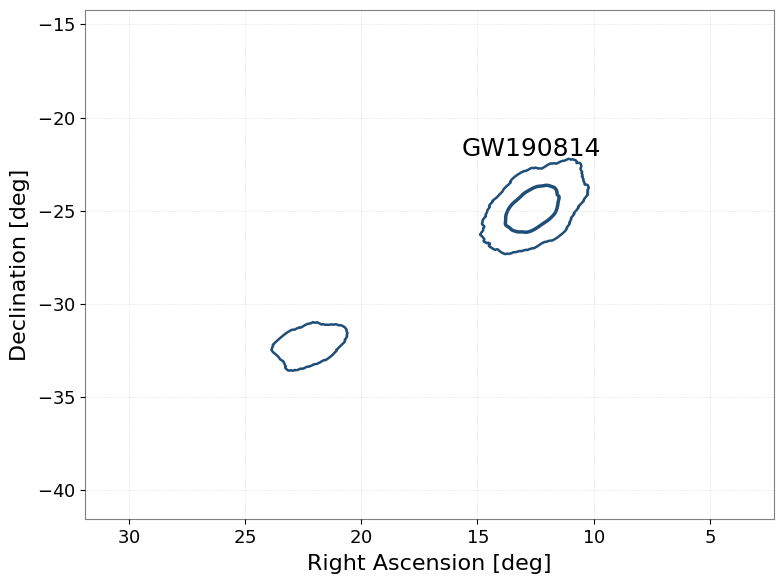

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.contour(
    ra_grid, dec_grid, cred_grid,
    levels=[0.5, 0.9],
    colors=["#1f4e79", "#1f4e79"],
    linewidths=[2.5, 1.8]
)

ax.text(
    peak_ra if peak_ra < 180 else peak_ra - 360,
    peak_dec + 2.5,
    "GW190814",
    fontsize=18,
    ha="center",
    va="bottom"
)

ax.set_xlabel("Right Ascension [deg]", fontsize=16)
ax.set_ylabel("Declination [deg]", fontsize=16)
ax.set_xlim(ra_max, ra_min)
ax.set_ylim(dec_min, dec_max)
ax.grid(True, linestyle=":", alpha=0.5)
ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_828/3497304097.py:10: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob = hp.read_map(skymap_file, field=0, verbose=False)


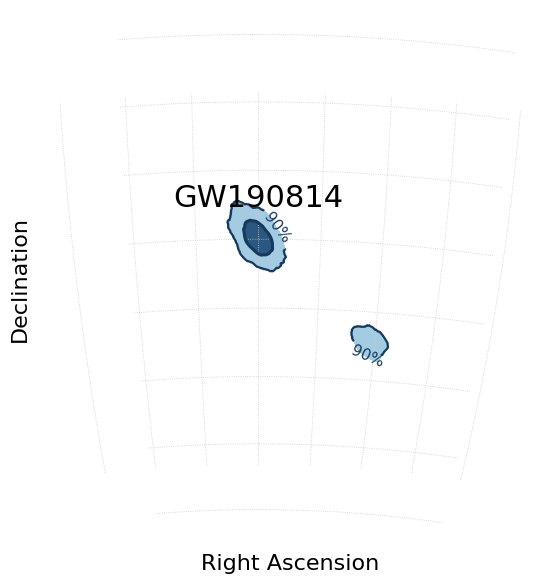

In [45]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# --------------------------------------------------
# Load skymap
# --------------------------------------------------
skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0, verbose=False)

nside = hp.get_nside(prob)
npix = len(prob)

# --------------------------------------------------
# Greedy credible levels
# --------------------------------------------------
order = np.argsort(prob)[::-1]
cdf = np.cumsum(prob[order])
credible = np.empty_like(prob)
credible[order] = cdf

# --------------------------------------------------
# HEALPix pixel centers -> RA, Dec
# --------------------------------------------------
ipix = np.arange(npix)
theta, phi = hp.pix2ang(nside, ipix)

ra = np.degrees(phi)                  # 0..360
dec = 90.0 - np.degrees(theta)        # -90..90

# Peak location
peak = np.argmax(prob)
ra0 = ra[peak]
dec0 = dec[peak]

# Wrap RA near the peak
ra_wrap = ((ra - ra0 + 180) % 360) - 180

# --------------------------------------------------
# Focus on localization region
# --------------------------------------------------
mask90 = credible <= 0.9
ra90 = ra_wrap[mask90]
dec90 = dec[mask90]

margin_ra = 8
margin_dec = 8

ra_min = ra90.min() - margin_ra
ra_max = ra90.max() + margin_ra
dec_min = dec90.min() - margin_dec
dec_max = dec90.max() + margin_dec

# Grid in RA/Dec around peak
nx, ny = 500, 500
ra_grid, dec_grid = np.meshgrid(
    np.linspace(ra_min, ra_max, nx),
    np.linspace(dec_min, dec_max, ny)
)

cred_grid = griddata(
    np.column_stack([ra_wrap, dec]),
    credible,
    (ra_grid, dec_grid),
    method="linear"
)

# --------------------------------------------------
# Orthographic projection centered on peak
# --------------------------------------------------
def ortho_project(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    ra0_rad = np.radians(ra0_deg)
    dec0_rad = np.radians(dec0_deg)

    dra = ra_rad - ra0_rad

    x = np.cos(dec_rad) * np.sin(dra)
    y = (np.cos(dec0_rad) * np.sin(dec_rad)
         - np.sin(dec0_rad) * np.cos(dec_rad) * np.cos(dra))
    return x, y

# Convert local wrapped RA back to absolute RA for projection
ra_abs_grid = ra_grid + ra0
xg, yg = ortho_project(ra_abs_grid, dec_grid, ra0, dec0)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Curved graticule: constant declination
dec_lines = np.arange(np.floor(dec_min/5)*5, np.ceil(dec_max/5)*5 + 1, 5)
ra_lines  = np.arange(np.floor(ra_min/5)*5, np.ceil(ra_max/5)*5 + 1, 5)

for d in dec_lines:
    ra_line = np.linspace(ra_min, ra_max, 400) + ra0
    dec_line = np.full_like(ra_line, d)
    x, y = ortho_project(ra_line, dec_line, ra0, dec0)
    ax.plot(x, y, color="0.8", lw=0.6, ls=":")

for r in ra_lines:
    dec_line = np.linspace(dec_min, dec_max, 400)
    ra_line = np.full_like(dec_line, r + ra0)
    x, y = ortho_project(ra_line, dec_line, ra0, dec0)
    ax.plot(x, y, color="0.8", lw=0.6, ls=":")

# Filled contours
ax.contourf(
    xg, yg, cred_grid,
    levels=[0, 0.5, 0.9],
    colors=["#1f4e79", "#9ecae1"],
    alpha=0.95
)

# Contour outlines
cs = ax.contour(
    xg, yg, cred_grid,
    levels=[0.5, 0.9],
    colors=["#163a5f"],
    linewidths=[2.2, 1.6]
)

# Label contours
fmt = {0.5: "50%", 0.9: "90%"}
ax.clabel(cs, fmt=fmt, inline=True, fontsize=11)

# Event label at peak
xp, yp = ortho_project(ra0, dec0, ra0, dec0)
ax.text(xp, yp + 0.03, "GW190814", fontsize=22, ha="center", va="bottom")

# Axis labels: keep intuitive local offsets
ax.set_xlabel("Right Ascension", fontsize=16)
ax.set_ylabel("Declination", fontsize=16)

# Clean look
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [46]:
!pip install astropy reproject healpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.1 MB/s eta 0:00:00
  Created wheel for pims: filename=PIMS-0.7-py3-none-any.whl size=84590 sha256=64f5c419b0febf05d2a45e2cbbf7b5c8ad5799a65bd11ece2c60c59e791c282d
  Stored in directory: /root/.cache/pip/wheels/be/9c/72/7cb84823aaa980c2e44064caae0ba869239270fac14f7129aa
Successfully built pims


/tmp/ipykernel_828/3835145423.py:13: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob = hp.read_map(skymap_file, field=0, verbose=False)


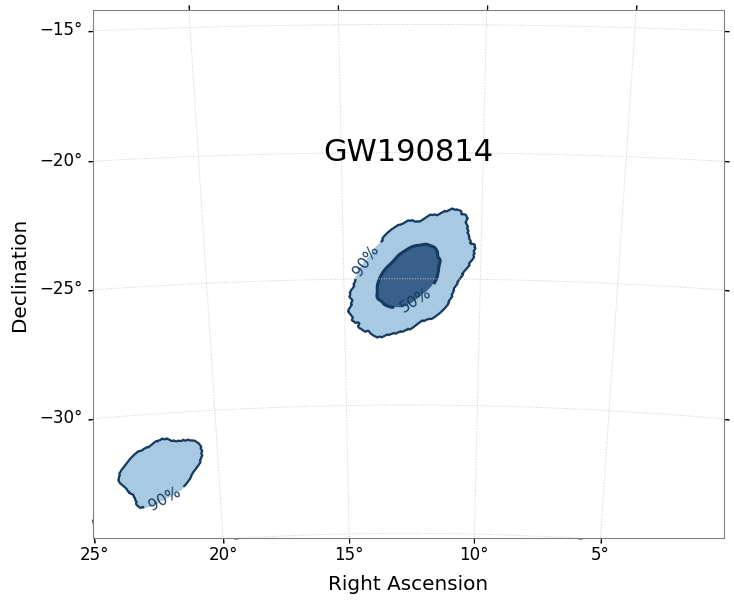

In [47]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_from_healpix

# --------------------------------------------------
# Load GW190814 skymap
# --------------------------------------------------
skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0, verbose=False)

nside = hp.get_nside(prob)
npix = len(prob)

# --------------------------------------------------
# Greedy credible levels
# --------------------------------------------------
order = np.argsort(prob)[::-1]
cdf = np.cumsum(prob[order])
credible = np.empty_like(prob)
credible[order] = cdf

# Peak location
ipix_peak = np.argmax(prob)
theta0, phi0 = hp.pix2ang(nside, ipix_peak)
ra0 = np.degrees(phi0)
dec0 = 90 - np.degrees(theta0)

# --------------------------------------------------
# Build WCS tangent-plane projection centered on source
# --------------------------------------------------
nx, ny = 700, 700
pixscale = 0.03  # deg/pixel; tune if needed

w = WCS(naxis=2)
w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
w.wcs.crval = [ra0, dec0]
w.wcs.crpix = [nx / 2, ny / 2]
w.wcs.cdelt = np.array([-pixscale, pixscale])

# Reproject credible-level map, not probability heatmap
array, footprint = reproject_from_healpix(
    (credible, "ICRS"),
    output_projection=w,
    shape_out=(ny, nx),
    nested=False
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig = plt.figure(figsize=(7.5, 6.2))
ax = plt.subplot(projection=w)

# Very light fill for 90%, darker fill for 50%
ax.contourf(
    array,
    levels=[0, 0.5, 0.9],
    colors=["#234f7d", "#9ec3df"],
    alpha=0.9
)

# Contour outlines
cs = ax.contour(
    array,
    levels=[0.5, 0.9],
    colors="#163a5f",
    linewidths=[2.2, 1.6]
)

# Label contours
ax.clabel(cs, fmt={0.5: "50%", 0.9: "90%"}, inline=True, fontsize=11)

# Grid
ax.coords.grid(True, color="0.8", linestyle=":", linewidth=0.7)

# Axis labels
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")

# Format ticks
ax.coords[0].set_major_formatter("d")
ax.coords[1].set_major_formatter("d")

# Event label near center
ax.text(
    0.5, 0.73, "GW190814",
    transform=ax.transAxes,
    ha="center", va="center",
    fontsize=22, color="black"
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_828/4178415577.py:12: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob = hp.read_map(skymap_file, field=0, verbose=False)


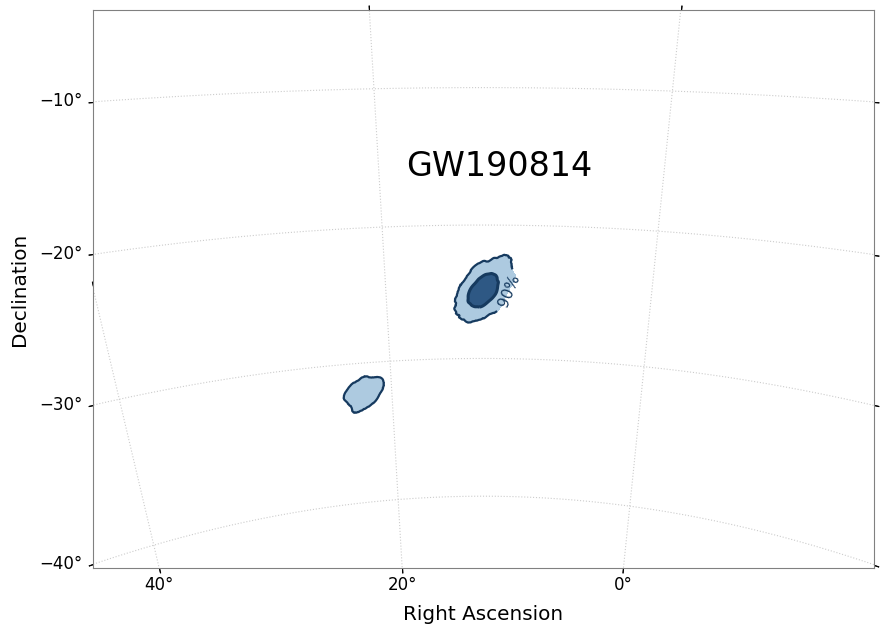

In [48]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from reproject import reproject_from_healpix

# --------------------------------------------------
# Load GW190814 skymap
# --------------------------------------------------
skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0, verbose=False)

nside = hp.get_nside(prob)

# Greedy credible levels
order = np.argsort(prob)[::-1]
cdf = np.cumsum(prob[order])
credible = np.empty_like(prob)
credible[order] = cdf

# Peak location
ipix_peak = np.argmax(prob)
theta0, phi0 = hp.pix2ang(nside, ipix_peak)
ra0 = np.degrees(phi0)
dec0 = 90 - np.degrees(theta0)

# --------------------------------------------------
# Build a wider TAN projection
# Wider field => visible curvature
# --------------------------------------------------
nx, ny = 900, 700
pixscale = 0.10   # deg/pixel  -> about 54 x 42 deg field

w = WCS(naxis=2)
w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
w.wcs.crval = [ra0, dec0]
w.wcs.crpix = [nx / 2, ny / 2]
w.wcs.cdelt = np.array([-pixscale, pixscale])

array, footprint = reproject_from_healpix(
    (credible, "ICRS"),
    output_projection=w,
    shape_out=(ny, nx),
    nested=False
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig = plt.figure(figsize=(9, 6.5))
ax = plt.subplot(projection=w)

# Fills
ax.contourf(
    array,
    levels=[0, 0.5, 0.9],
    colors=["#234f7d", "#a9c7df"],
    alpha=0.95
)

# Outlines
cs = ax.contour(
    array,
    levels=[0.5, 0.9],
    colors="#163a5f",
    linewidths=[2.2, 1.6]
)

ax.clabel(cs, fmt={0.5: "50%", 0.9: "90%"}, inline=True, fontsize=11)

# Grid
ax.coords.grid(True, color="0.8", linestyle=":", linewidth=0.8)

# Labels
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.coords[0].set_major_formatter("d")
ax.coords[1].set_major_formatter("d")

# Event label
ax.text(
    0.52, 0.72, "GW190814",
    transform=ax.transAxes,
    ha="center", va="center",
    fontsize=24, color="black"
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_828/3075558431.py:15: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob = hp.read_map(skymap_file, field=0, verbose=False)


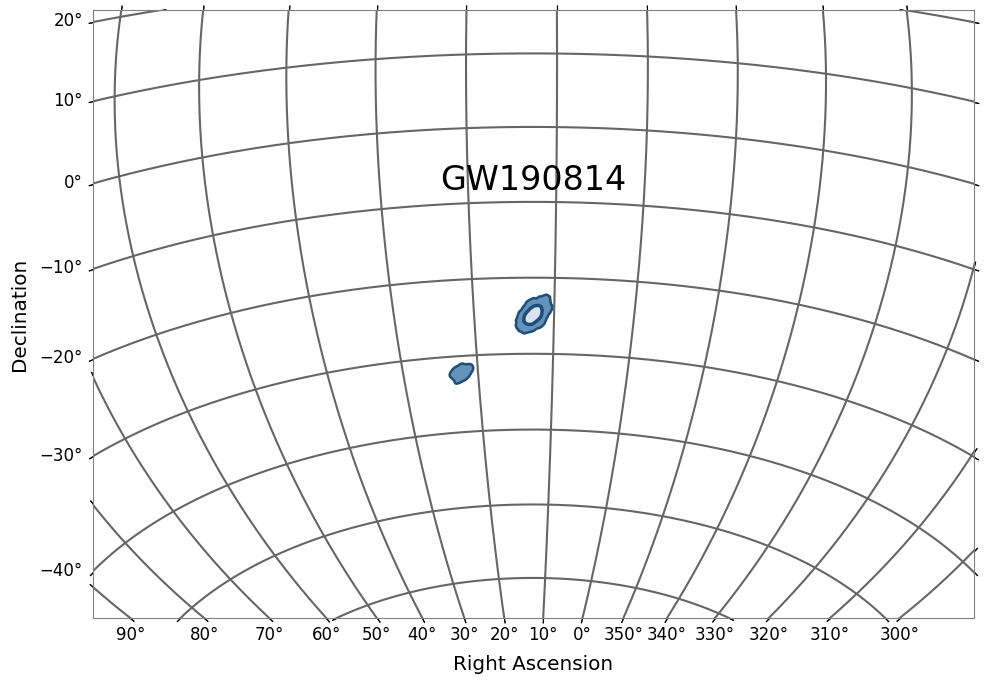

In [52]:
!pip install astropy reproject healpy

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from reproject import reproject_from_healpix
import astropy.units as u

# --------------------------------------------------
# Load skymap
# --------------------------------------------------
skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0, verbose=False)

nside = hp.get_nside(prob)

# --------------------------------------------------
# Compute credible levels
# --------------------------------------------------
order = np.argsort(prob)[::-1]
cdf = np.cumsum(prob[order])
credible = np.empty_like(prob)
credible[order] = cdf

# --------------------------------------------------
# Find peak (center of projection)
# --------------------------------------------------
ipix_peak = np.argmax(prob)
theta0, phi0 = hp.pix2ang(nside, ipix_peak)

ra0 = np.degrees(phi0)
dec0 = 90 - np.degrees(theta0)

# --------------------------------------------------
# Build WCS (WIDE FIELD for curvature)
# --------------------------------------------------
nx, ny = 1000, 800
pixscale = 0.10   # degrees per pixel → large sky area

w = WCS(naxis=2)
w.wcs.ctype = ["RA---ZEA", "DEC--ZEA"]
w.wcs.crval = [ra0, dec0]
w.wcs.crpix = [nx / 2, ny / 2]
w.wcs.cdelt = np.array([-pixscale, pixscale])

# --------------------------------------------------
# Reproject credible levels
# --------------------------------------------------
array, footprint = reproject_from_healpix(
    (credible, "ICRS"),
    output_projection=w,
    shape_out=(ny, nx),
    nested=False
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(projection=w)

# Filled regions (lighter outer, darker inner)
ax.contourf(
    array,
    levels=[0, 0.5, 0.9],
    colors=["#d6e4f0", "#5b8db8"],
    alpha=0.95
)

# Contour outlines
cs = ax.contour(
    array,
    levels=[0.5, 0.9],
    colors="#1f4e79",
    linewidths=[2.5, 1.8]
)

# Label contours
ax.clabel(cs, fmt={0.5: "50%", 0.9: "90%"}, inline=True, fontsize=11)

# --------------------------------------------------
# STRONG GRIDLINES (this is the key visual fix)
# --------------------------------------------------
ax.coords.grid(True, color="0.4", linestyle="-", linewidth=1.5)

# Optional: control spacing (cleaner grid)
ax.coords[0].set_ticks(spacing=10 * u.deg)
ax.coords[1].set_ticks(spacing=10 * u.deg)

# Axis labels
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")

# Format ticks
ax.coords[0].set_major_formatter("d")
ax.coords[1].set_major_formatter("d")

# Event label
ax.text(
    0.5, 0.72, "GW190814",
    transform=ax.transAxes,
    ha="center", va="center",
    fontsize=24
)


plt.tight_layout()
plt.show()

/tmp/ipykernel_828/1034662845.py:15: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  prob = hp.read_map(skymap_file, field=0, verbose=False)


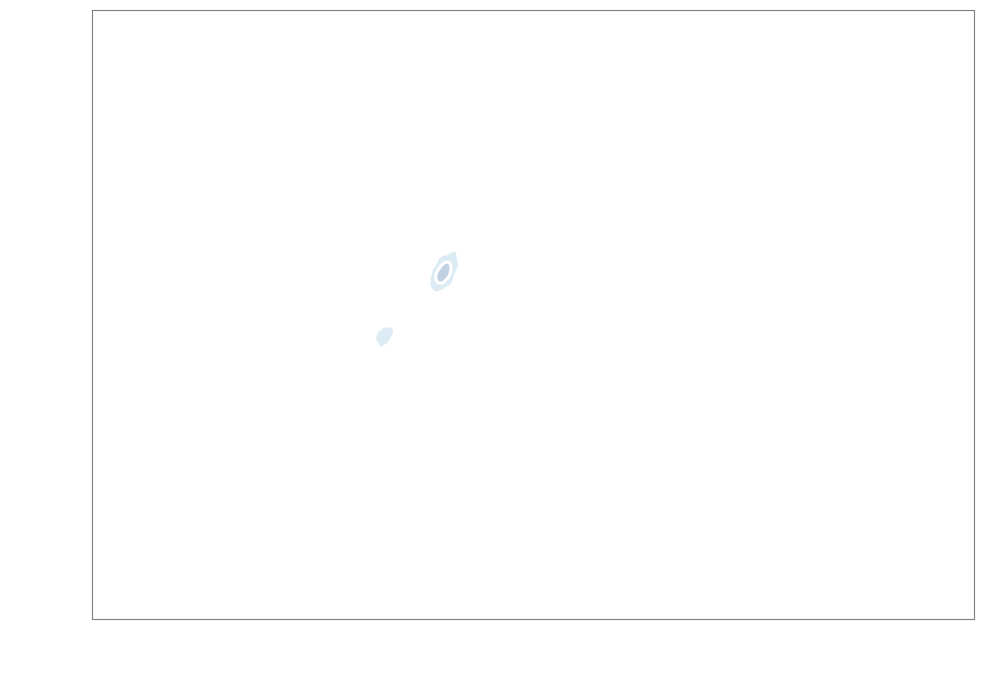

In [54]:
!pip install astropy reproject healpy

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from reproject import reproject_from_healpix
import astropy.units as u

# --------------------------------------------------
# Load skymap
# --------------------------------------------------
skymap_file = "GW190814_skymap.fits.gz"
prob = hp.read_map(skymap_file, field=0, verbose=False)

nside = hp.get_nside(prob)

# --------------------------------------------------
# Compute credible levels
# --------------------------------------------------
order = np.argsort(prob)[::-1]
cdf = np.cumsum(prob[order])
credible = np.empty_like(prob)
credible[order] = cdf

# --------------------------------------------------
# Find peak
# --------------------------------------------------
ipix_peak = np.argmax(prob)
theta0, phi0 = hp.pix2ang(nside, ipix_peak)
ra0 = np.degrees(phi0)
dec0 = 90 - np.degrees(theta0)

# --------------------------------------------------
# WCS projection (wide-field)
# --------------------------------------------------
nx, ny = 1000, 800
pixscale = 0.10

w = WCS(naxis=2)
w.wcs.ctype = ["RA---ZEA", "DEC--ZEA"]
w.wcs.crval = [ra0, dec0]
w.wcs.crpix = [nx / 2, ny / 2]
w.wcs.cdelt = np.array([-pixscale, pixscale])

# --------------------------------------------------
# Reproject credible levels
# --------------------------------------------------
array, footprint = reproject_from_healpix(
    (credible, "ICRS"),
    output_projection=w,
    shape_out=(ny, nx),
    nested=False
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig = plt.figure(figsize=(10, 7), facecolor="none")
ax = plt.subplot(projection=w)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Subtle fills
ax.contourf(
    array,
    levels=[0, 0.5, 0.9],
    colors=["#4f7cac", "#9ecae1"],
    alpha=0.35
)

# White contours
cs = ax.contour(
    array,
    levels=[0.5, 0.9],
    colors="white",
    linewidths=[2.2, 1.6]
)

ax.clabel(cs, fmt={0.5: "50%", 0.9: "90%"}, inline=True, fontsize=12, colors="white")

# White grid
ax.coords.grid(True, color="white", linestyle="-", linewidth=1.2, alpha=0.7)

# Ticks
ax.coords[0].set_ticks(spacing=10 * u.deg)
ax.coords[1].set_ticks(spacing=10 * u.deg)

# Labels
ax.coords[0].set_axislabel("Right Ascension", color="white", fontsize=14)
ax.coords[1].set_axislabel("Declination", color="white", fontsize=14)

# Tick labels white
ax.tick_params(colors="white")
ax.coords[0].set_major_formatter("d")
ax.coords[1].set_major_formatter("d")

# Event label
ax.text(
    0.5, 0.72, "GW190814",
    transform=ax.transAxes,
    ha="center", va="center",
    fontsize=26,
    color="white"
)

# --------------------------------------------------
# Crop back to the wider view from your screenshot
# --------------------------------------------------
x1, y1 = ax.wcs.world_to_pixel_values(95, -45)
x2, y2 = ax.wcs.world_to_pixel_values(295, 20)

ax.set_xlim(min(x1, x2), max(x1, x2))
ax.set_ylim(min(y1, y2), max(y1, y2))

# Save
plt.savefig("gw190814_skymap_white_wide.png", dpi=300, transparent=True, bbox_inches="tight")

plt.tight_layout()
plt.show()